#**PCA**

**Apply PCA to reduce the dataset to 2 principal components.**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


iris = load_iris(as_frame=True)
df = iris.data.copy()
df['species'] = iris.target
df['species_name'] = df['species'].map(dict(enumerate(iris.target_names)))

X = iris.data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)
print("Total variance captured by 2 PCs: {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100))


Explained variance ratio (PC1, PC2): [0.72962445 0.22850762]
Total variance captured by 2 PCs: 95.81%


**Visualize the transformed data.**

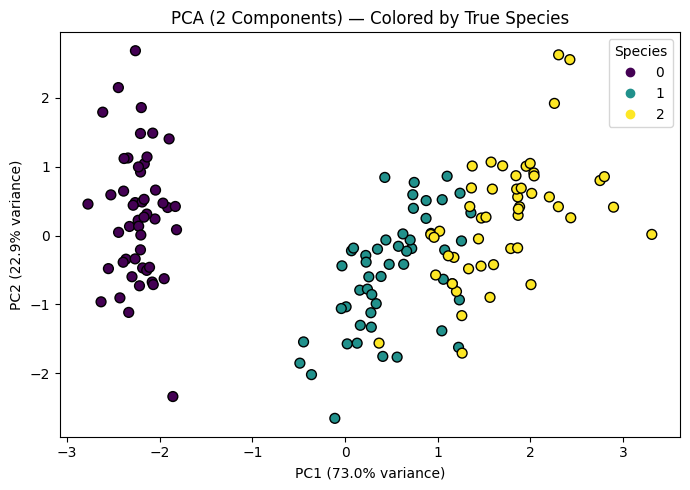

Saved pca_visualization.png


In [4]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    df['pca1'], df['pca2'],
    c=df['species'], cmap='viridis', edgecolor='k', s=50
)
plt.title("PCA (2 Components) — Colored by True Species")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(*scatter.legend_elements(), title="Species")
plt.tight_layout()
plt.savefig("pca_visualization.png", dpi=150)
plt.show()
print("Saved pca_visualization.png")


**Compare the PCA visualization with the clustering results.**